# <font color='#ff7a5c'>Projeto Prático: Classificação de Imagens com STL-10</font>

* **Aluno:** Rui Gonçalves de Oliveira Júnior
* **Matrícula:** 201910831
* **Curso:** Engenharia da Computação
* **Disciplina:** Laboratório de Inovação e Automação 1 (LIA1)
* **Data da Atividade:** 31/03/2026

---

## <font color='#ff7a5c'>1. Introdução e Arquitetura</font>

Este notebook documenta a construção de um modelo de aprendizado de máquina para o dataset **STL-10**. Para superar o desafio da alta resolução (96x96 pixels) combinada ao baixo volume de dados de treinamento (5.000 imagens), foram implementadas três abordagens avançadas de visão computacional:

1. **Data Augmentation:** Mutações sintéticas em tempo real para evitar o sobreajuste (*overfitting*).
2. **Transfer Learning (VGG16):** Utilização de pesos pré-treinados no ImageNet para extração robusta de características geométricas.
3. **Explainable AI (Grad-CAM):** Geração de mapas de calor analíticos para justificar matematicamente as decisões da rede neural.


## <font color='#ff7a5c'>2. Preparação do Ambiente</font>

Importação das bibliotecas fundamentais para a construção do grafo computacional (`tensorflow`), manipulação de matrizes matemáticas (`numpy`), aquisição de dados em nuvem (`tensorflow_datasets`) e visualização gráfica dos resultados estatísticos.

In [1]:
!pip install -q tensorflow tensorflow-datasets opencv-python

import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns
import cv2
from PIL import Image

print(f"Versão do TensorFlow: {tf.__version__}")

Versão do TensorFlow: 2.19.0


## <font color='#ff7a5c'>3. Aquisição e Tratamento dos Dados</font>

Os dados são extraídos do repositório oficial de Stanford. Para otimizar o processamento em execuções futuras, o repositório é mapeado diretamente para o Google Drive do usuário.

Nesta etapa, aplicamos a **Normalização Min-Max**: os valores de intensidade dos pixels (originalmente de 0 a 255) são divididos por 255.0. Esse reescalonamento para o intervalo [0, 1] é fundamental para garantir a estabilidade numérica e a rápida convergência dos gradientes durante o treinamento da rede neural.

In [ ]:
from google.colab import drive
import os

# 1. Conecta o seu Google Drive ao Colab (vai pedir sua permissão)
print("Conectando ao Google Drive...")
drive.mount('/content/drive')

# 2. Cria uma pasta chamada 'Datasets' no seu Drive (se não existir)
caminho_meu_drive = '/content/drive/MyDrive/Datasets'
os.makedirs(caminho_meu_drive, exist_ok=True)

print("\nVerificando e carregando o dataset STL-10 do Google Drive...")
# 3. O 'data_dir' força o TensorFlow a salvar e ler direto do seu Drive!
dataset, info = tfds.load('stl10',
                          split=['train', 'test'],
                          batch_size=-1,
                          as_supervised=True,
                          with_info=True,
                          data_dir=caminho_meu_drive)

# Extração e conversão para NumPy
imagens_treino, labels_treino = tfds.as_numpy(dataset[0])
imagens_teste, labels_teste = tfds.as_numpy(dataset[1])

labels_treino = labels_treino.reshape(-1, 1)
labels_teste = labels_teste.reshape(-1, 1)

nomes_classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Normalização
imagens_treino = imagens_treino / 255.0
imagens_teste = imagens_teste / 255.0

print(f"Formato dos dados de treino: {imagens_treino.shape}")
print("Tudo pronto! Nas próximas execuções, o download será pulado.")

## <font color='#ff7a5c'>4. Inspeção Visual dos Dados</font>

Exibição de uma amostra inicial do conjunto de treinamento para validação da integridade do dataset e observação da resolução nativa (96x96) das categorias abordadas.

Amostras do Conjunto de Treinamento:


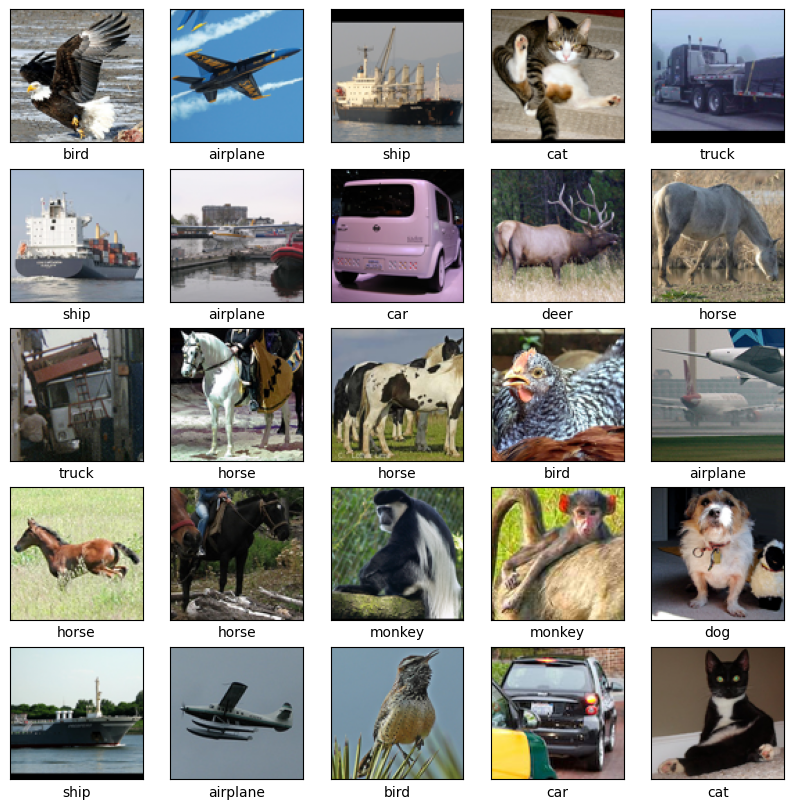

In [8]:
def visualiza_imagens(images, labels):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(nomes_classes[labels[i][0]])
    plt.show()

print("Amostras do Conjunto de Treinamento:")
visualiza_imagens(imagens_treino, labels_treino)

## <font color='#ff7a5c'>5. Arquitetura Neural e Transfer Learning</font>

A arquitetura foi estruturada utilizando a **API Funcional** do TensorFlow, o que permite um mapeamento explícito do fluxo de tensores (ideal para a auditoria do Grad-CAM nas etapas finais).

O modelo inicia com uma camada de **Data Augmentation** (aplicando giros e zooms aleatórios). Em seguida, acopla-se a base convolucional da rede **VGG16** com seus pesos congelados (*Transfer Learning*), atuando como um poderoso extrator de características pré-treinado. Por fim, um cabeçalho de classificação denso (MLP) com a função de ativação `softmax` é adicionado para mapear as características extraídas para as 10 classes do STL-10.

In [11]:
# 1. Data Augmentation (Sintaxe atualizada Keras 3)
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(96, 96, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
    layers.RandomRotation(0.1)
], name="data_augmentation")

# 2. Transfer Learning (VGG16)
base_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
base_model.trainable = False

# 3. Construção Final Unificada
modelo_lia = models.Sequential()

# Adicionamos a entrada explicitamente
modelo_lia.add(layers.Input(shape=(96, 96, 3)))
modelo_lia.add(data_augmentation)

# O Pulo do Gato: base_model.layers[1:] ignora a InputLayer da VGG16
for layer in base_model.layers[1:]:
    modelo_lia.add(layer)

# 4. Cabeçalho de Classificação
modelo_lia.add(layers.GlobalAveragePooling2D())
modelo_lia.add(layers.Dense(128, activation='relu'))
modelo_lia.add(layers.Dropout(0.3))
modelo_lia.add(layers.Dense(10, activation='softmax'))

modelo_lia.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## <font color='#ff7a5c'>6. Compilação e Treinamento (Early Stopping)</font>

O treinamento é configurado com o otimizador `Adam`. Para mitigar o risco de *overfitting*, implementa-se o mecanismo de **Early Stopping** (Parada Antecipada). O algoritmo monitora a função de perda no conjunto de validação (`val_loss`); caso a rede não apresente melhorias de generalização por 6 ciclos consecutivos, o processamento é interrompido e o sistema restaura automaticamente os melhores pesos matemáticos encontrados.

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

modelo_lia.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Treinando modelo...")
history = modelo_lia.fit(imagens_treino, labels_treino,
                         epochs=50,
                         validation_data=(imagens_teste, labels_teste),
                         callbacks=[early_stop])

Treinando modelo...
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.3700 - loss: 1.7031 - val_accuracy: 0.5621 - val_loss: 1.2872
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.5182 - loss: 1.3190 - val_accuracy: 0.6467 - val_loss: 1.0834
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.5696 - loss: 1.1888 - val_accuracy: 0.6611 - val_loss: 0.9890
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.5906 - loss: 1.1153 - val_accuracy: 0.6735 - val_loss: 0.9421
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.6168 - loss: 1.0508 - val_accuracy: 0.6844 - val_loss: 0.9054
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.6260 - loss: 1.0315 - val_accuracy: 0.6999 - val_loss: 0.8725
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.6376 - loss: 1.0072 - val_accuracy: 0.6861 - val_loss: 0.8813
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.6

## <font color='#ff7a5c'>7. Curvas de Aprendizado e Convergência</font>

A análise simultânea das curvas de Acurácia e de Perda (Loss) permite diagnosticar o comportamento do algoritmo ao longo das épocas. A proximidade entre as curvas de treinamento e validação indica que o modelo obteve uma generalização saudável, suportada pelas camadas de regularização e *Data Augmentation*.

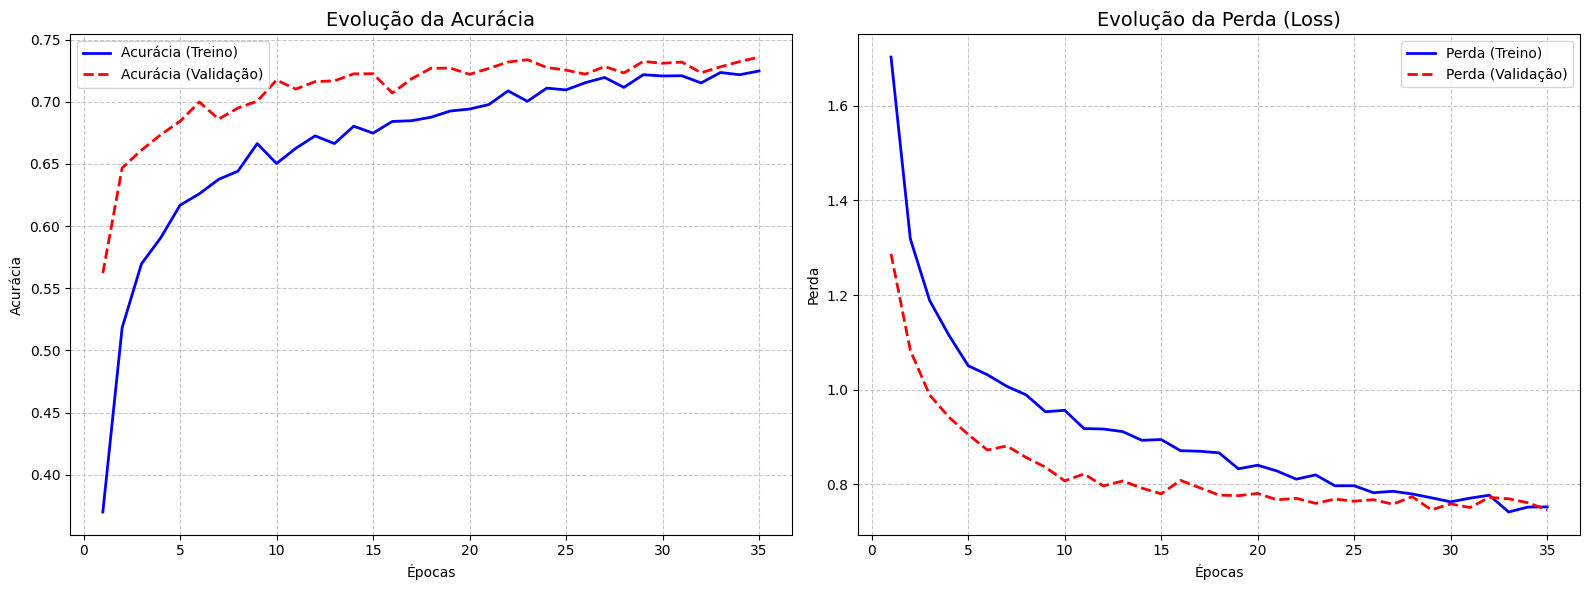

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epocas = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(epocas, acc, 'b-', label='Acurácia (Treino)', linewidth=2)
axes[0].plot(epocas, val_acc, 'r--', label='Acurácia (Validação)', linewidth=2)
axes[0].set_title('Evolução da Acurácia', fontsize=14)
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].plot(epocas, loss, 'b-', label='Perda (Treino)', linewidth=2)
axes[1].plot(epocas, val_loss, 'r--', label='Perda (Validação)', linewidth=2)
axes[1].set_title('Evolução da Perda (Loss)', fontsize=14)
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Perda')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## <font color='#ff7a5c'>8. Avaliação Analítica e Matriz de Confusão</font>

Para uma validação acadêmica rigorosa, extrai-se o **Classification Report**, contemplando três indicadores além da acurácia global:
* **Precisão (Precision):** Mensura o nível de falsos positivos da classe.
* **Revocação (Recall):** Mensura a recuperação efetiva, indicando falsos negativos.
* **F1-Score:** Média harmônica que atesta a robustez do aprendizado.

A **Matriz de Confusão** espacializa essas distribuições, evidenciando o volume de inferências corretas em sua diagonal principal.

-> Acurácia Global Final: 73.25%

RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:

              precision    recall  f1-score   support

    airplane       0.85      0.80      0.82       800
        bird       0.76      0.75      0.75       800
         car       0.89      0.86      0.88       800
         cat       0.60      0.65      0.62       800
        deer       0.65      0.79      0.71       800
         dog       0.62      0.54      0.58       800
       horse       0.76      0.68      0.72       800
      monkey       0.69      0.62      0.65       800
        ship       0.76      0.86      0.81       800
       truck       0.77      0.78      0.78       800

    accuracy                           0.73      8000
   macro avg       0.73      0.73      0.73      8000
weighted avg       0.73      0.73      0.73      8000



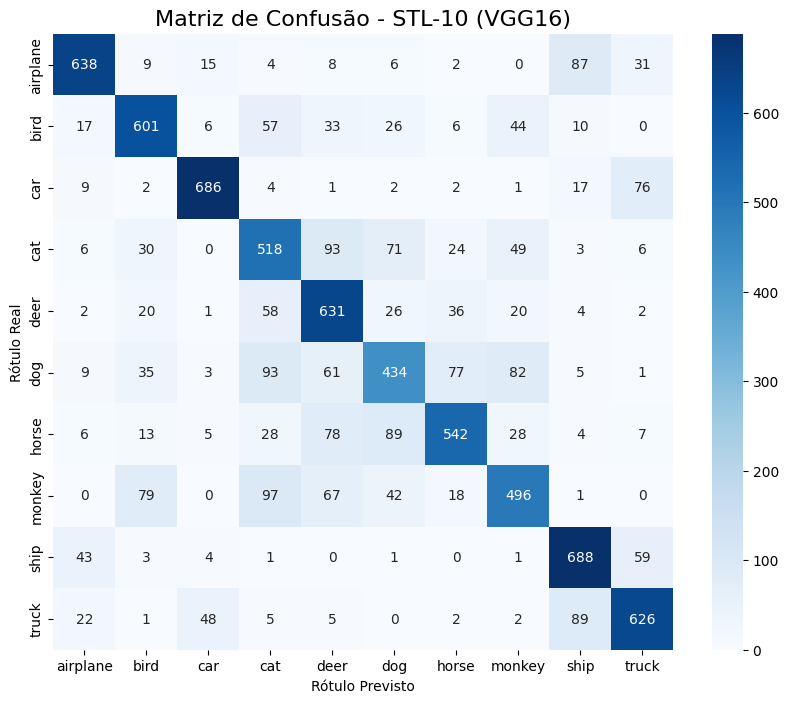

In [14]:
from sklearn.metrics import classification_report, confusion_matrix

loss_teste, acc_teste = modelo_lia.evaluate(imagens_teste, labels_teste, verbose=0)
print("="*65)
print(f"-> Acurácia Global Final: {acc_teste*100:.2f}%")
print("="*65 + "\n")

y_pred = modelo_lia.predict(imagens_teste, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = labels_teste.flatten()

print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO:\n")
print(classification_report(y_true, y_pred_classes, target_names=nomes_classes))

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - STL-10 (VGG16)', fontsize=16)
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.show()

## <font color='#ff7a5c'>9. Desempenho Isolado por Classe</font>

Extração e ordenação matemática da acurácia exata de cada uma das 10 categorias, permitindo identificar quais padrões visuais foram absorvidos com maior facilidade pela base convolucional da rede.

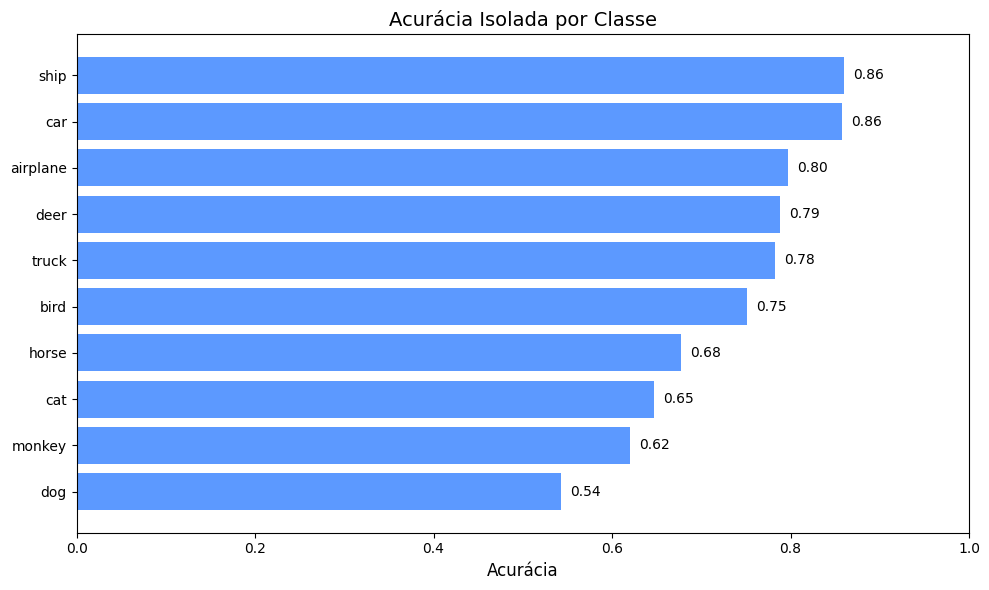

In [53]:
acuracia_por_classe = cm.diagonal() / cm.sum(axis=1)
desempenho_classes = list(zip(nomes_classes, acuracia_por_classe))
desempenho_classes.sort(key=lambda x: x[1])

classes_ordenadas, acc_ordenada = zip(*desempenho_classes)

plt.figure(figsize=(10, 6))
bars = plt.barh(classes_ordenadas, acc_ordenada, color='#5c99ff')
plt.title('Acurácia Isolada por Classe', fontsize=14)
plt.xlabel('Acurácia', fontsize=12)
plt.xlim(0, 1)

for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}',
             va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

## <font color='#ff7a5c'>10. Análise de Erros</font>

Para compreender as limitações do modelo, esta etapa isola as falhas de predição ao zerar a diagonal de acertos da matriz. O gráfico consolida os **10 pares de classes com maior incidência de troca**, geralmente ocasionados por sobreposição de texturas, formatos geométricos ou cenários de fundo semelhantes entre as imagens.

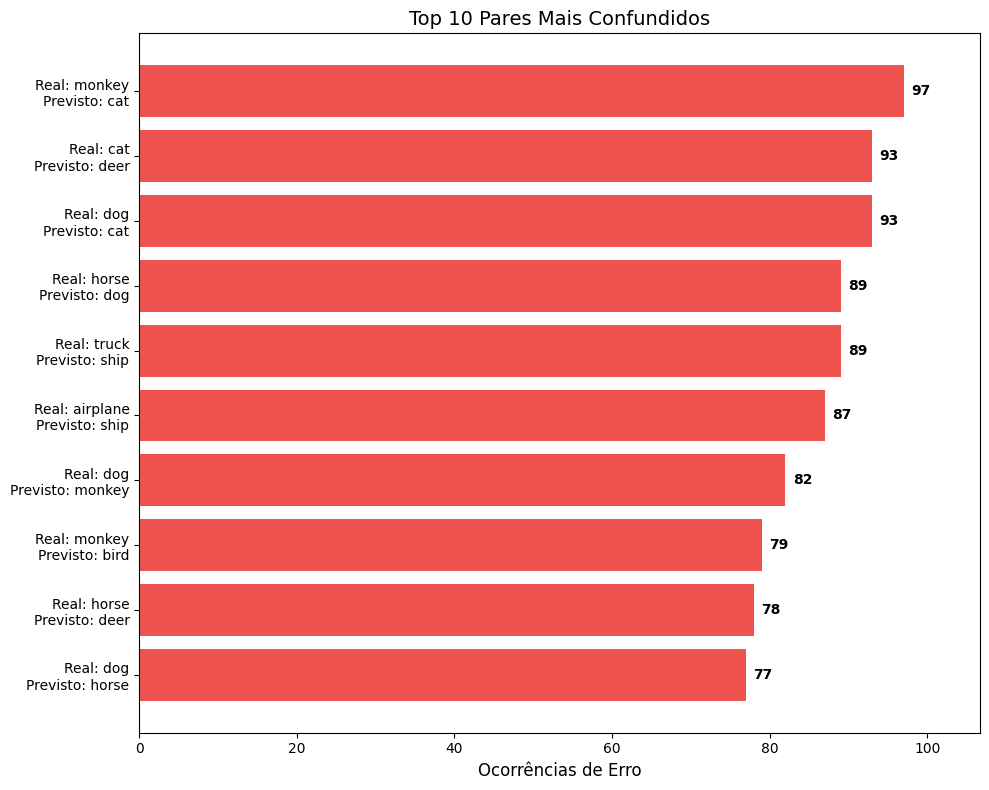

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Recalculando as previsões e a matriz de confusão com um nome à prova de conflitos
y_pred = modelo_lia.predict(imagens_teste, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = labels_teste.flatten()

matriz_confusao = confusion_matrix(y_true, y_pred_classes)

# 2. Criação de uma cópia para preservação dos dados originais
cm_erros = matriz_confusao.copy()
np.fill_diagonal(cm_erros, 0)
pares_erro = []

# Mapeamento apenas dos pares que apresentaram erros
for i in range(cm_erros.shape[0]):
    for j in range(cm_erros.shape[1]):
        if i != j and cm_erros[i, j] > 0:
            pares_erro.append((nomes_classes[i], nomes_classes[j], cm_erros[i, j]))

# Ordenação decrescente para obter as maiores confusões
pares_erro.sort(key=lambda x: x[2], reverse=True)

# Seleção dos 10 pares com mais erros
top_10_erros = pares_erro[:10]
labels_erros = [f"Real: {p[0]}\nPrevisto: {p[1]}" for p in top_10_erros]
valores_erros = [p[2] for p in top_10_erros]

# Configuração da figura com um único gráfico
plt.figure(figsize=(10, 8))

# Plotagem das barras horizontais
bars = plt.barh(labels_erros[::-1], valores_erros[::-1], color='#ef5350')
plt.title('Top 10 Pares Mais Confundidos', fontsize=14)
plt.xlabel('Ocorrências de Erro', fontsize=12)

# Ajuste do limite do eixo X para que os números não fiquem cortados
if valores_erros:
    plt.xlim(0, max(valores_erros) * 1.1)

# Adição dos valores na ponta de cada barra
for bar in bars:
    plt.text(bar.get_width() + (max(valores_erros) * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}',
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## <font color='#ff7a5c'>11. Inferência Básica</font>

Teste prático de predição submetendo a rede a um dado do mundo real. A imagem externa passa pelos mesmos processos de redimensionamento e normalização dos dados originais de treinamento antes da predição.

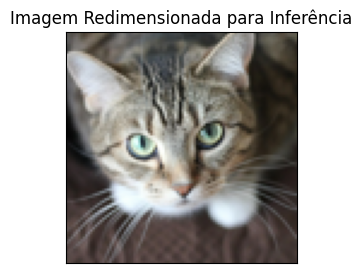

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
RESULTADO DA INFERÊNCIA
Classificação: CAT
Nível de Confiança: 99.60%


In [20]:
caminho_imagem = "/content/drive/MyDrive/Datasets/img1.png"

try:
    nova_imagem = Image.open(caminho_imagem).convert('RGB')
    nova_imagem_resized = nova_imagem.resize((96, 96))

    plt.figure(figsize=(3,3))
    plt.imshow(nova_imagem_resized)
    plt.xticks([])
    plt.yticks([])
    plt.title("Imagem Redimensionada para Inferência")
    plt.show()

    nova_imagem_array = np.array(nova_imagem_resized) / 255.0
    nova_imagem_array = np.expand_dims(nova_imagem_array, axis=0)

    previsoes = modelo_lia.predict(nova_imagem_array)

    classe_prevista = np.argmax(previsoes)
    nome_classe_prevista = nomes_classes[classe_prevista]
    confianca = np.max(previsoes) * 100

    print("="*50)
    print("RESULTADO DA INFERÊNCIA")
    print(f"Classificação: {nome_classe_prevista.upper()}")
    print(f"Nível de Confiança: {confianca:.2f}%")
    print("="*50)

except FileNotFoundError:
    print(f"\nERRO: O arquivo '{caminho_imagem}' não foi localizado no diretório especificado.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## <font color='#ff7a5c'>12. Explainable AI: Grad-CAM (Inspecionando a Decisão)</font>

Para comprovar que a rede neural aprendeu a interpretar formas e não apenas decorou dados de fundo, aplica-se o algoritmo **Grad-CAM** (*Gradient-weighted Class Activation Mapping*).

Esta técnica isola os gradientes matemáticos fluindo para a última camada de convolução, gerando um mapa térmico de ativação. A visualização revela de forma transparente **exatamente em quais pixels da foto a Inteligência Artificial focou sua atenção** para definir a classe prevista.

/tmp/ipykernel_1012/1287623475.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


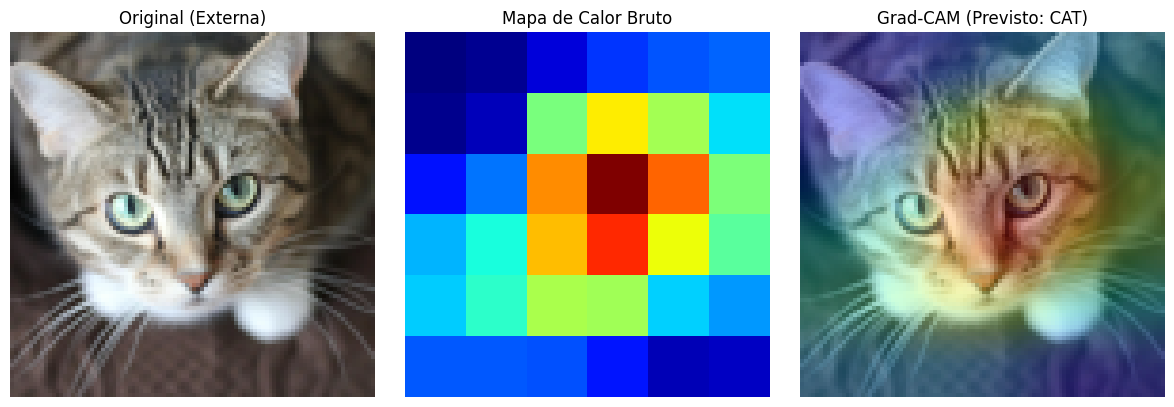

In [51]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

def get_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3"):
    # Procuramos onde a VGG16 começa de verdade, ignorando o Data Augmentation
    start_idx = 0
    for i, layer in enumerate(model.layers):
        if layer.name == 'block1_conv1':
            start_idx = i
            break

    # 2. Reconstruímos o caminho matemático de forma explícita e livre de erros
    inp = tf.keras.Input(shape=(96, 96, 3))
    x = inp
    conv_output = None

    # Passamos a imagem camada por camada usando os pesos que você já treinou
    for layer in model.layers[start_idx:]:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_output = x

    # Criamos um sub-modelo focado apenas no rastreamento dos gradientes
    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_output, x])

    # 3. gds
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + img * 255.0
    return tf.keras.utils.array_to_img(superimposed_img)

# ---------------------------------------------------------
# NOVA SEÇÃO: Carregando a imagem externa 'img1.png'
# ---------------------------------------------------------
caminho_imagem = "/content/drive/MyDrive/Datasets/img1.png"

try:
    # Abre a imagem, garante que está em RGB e redimensiona para 96x96
    nova_imagem = Image.open(caminho_imagem).convert('RGB')
    nova_imagem_resized = nova_imagem.resize((96, 96))

    # Converte para array do numpy e normaliza (escala de 0 a 1)
    img_teste = np.array(nova_imagem_resized) / 255.0

    # Expande a dimensão para simular um lote (batch) de 1 imagem: (1, 96, 96, 3)
    img_array = np.expand_dims(img_teste, axis=0)

    # Faz a Previsão
    preds = modelo_lia.predict(img_array, verbose=0)
    classe_nome = nomes_classes[np.argmax(preds)]

    # Gera o Mapa de Calor
    heatmap = get_gradcam_heatmap(img_array, modelo_lia)
    imagem_cam = display_gradcam(img_teste, heatmap)

    # Plotagem
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_teste)
    axes[0].set_title('Original (Externa)')
    axes[0].axis('off')

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Mapa de Calor Bruto')
    axes[1].axis('off')

    axes[2].imshow(imagem_cam)
    axes[2].set_title(f'Grad-CAM (Previsto: {classe_nome.upper()})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"\nERRO: O arquivo '{caminho_imagem}' não foi encontrado.")
    print("Por favor, faça o upload do arquivo 'img1.png' para o Colab antes de rodar.")

## <font color='#ff7a5c'>Apêndice: Tradução das Categorias do STL-10</font>

| Inglês (Original) | Tradução (Português) | | Inglês (Original) | Tradução (Português) |
| :--- | :--- | :---| :--- | :--- |
| **airplane** | avião | | **dog** | cachorro |
| **bird** | pássaro | | **horse** | cavalo |
| **car** | carro | | **monkey** | macaco |
| **cat** | gato | | **ship** | navio |
| **deer** | veado | | **truck** | caminhão |